In [30]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) =  cifar10.load_data()

In [3]:
animal = [2, 3, 4, 5, 6, 7]
vehicles = [0, 1, 8, 9]

In [4]:
y_train = y_train.flatten()
y_test = y_test.flatten()

In [5]:
for i in range(len(y_train)):
    if y_train[i] in vehicles:
        y_train[i] = 1
    else:
        y_train[i] = 0
y_train

array([0, 1, 1, ..., 1, 1, 1], dtype=uint8)

In [6]:
for i in range(len(y_test)):
    if y_test[i] in vehicles:
        y_test[i] = 1
    else:
        y_test[i] = 0

In [7]:
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)


In [8]:
x_train = x_train / 255
x_test = x_test / 255
x_train

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [15]:
y_test[0]

array([1., 0.])

In [43]:
sequential = Sequential([
    Conv2D (32, (3, 3), activation = "relu", input_shape = (32, 32, 3)),
    MaxPooling2D ((2, 2)),
    Conv2D (64, (3, 3), activation = "relu"),
    MaxPooling2D ((2, 2)),
    Conv2D (64, (3, 3), activation = "relu"),
    MaxPooling2D ((2, 2)),
    Flatten (),
    Dense(64, activation = "relu"),
    Dense(2, activation = "softmax")
])

In [12]:
y_train[0]

array([1., 0.])

In [45]:
sequential.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])
sequential.fit(x_train, y_train, epochs = 10, batch_size = 5, validation_split = 0.1, verbose = 1)

Epoch 1/10
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 70s 7ms/step - accuracy: 0.8812 - loss: 0.2887 - val_accuracy: 0.9084 - val_loss: 0.2344
Epoch 2/10
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - accuracy: 0.9074 - loss: 0.2317 - val_accuracy: 0.9152 - val_loss: 0.2116
Epoch 3/10
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.9186 - loss: 0.2075 - val_accuracy: 0.9224 - val_loss: 0.1954
Epoch 4/10
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - accuracy: 0.9253 - loss: 0.1876 - val_accuracy: 0.9214 - val_loss: 0.2035
Epoch 5/10
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - accuracy: 0.9337 - loss: 0.1701 - val_accuracy: 0.9228 - val_loss: 0.2066
Epoch 6/10
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - accuracy: 0.9385 - loss: 0.1575 - val_accuracy: 0.9264 - val_loss: 0.1942
Epoch 7/10
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - accuracy: 0.9438 - loss: 0.1446 - val_accuracy: 0.9314 - val_loss: 0.1764
Epoch 8/10
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 4169s 463ms/step - accuracy: 0.9468 - los

In [46]:
sequential.save("SequentialCNN.h5")

In [9]:
SequentialCNN = load_model("SequentialCNN.h5")

In [18]:
y_pred = SequentialCNN.predict(x_test)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[9.9420184e-01, 5.7981713e-03],
       [5.5982787e-09, 1.0000000e+00],
       [1.9434078e-02, 9.8056591e-01],
       ...,
       [9.9999380e-01, 6.2543963e-06],
       [9.1579252e-01, 8.4207468e-02],
       [9.9999654e-01, 3.4345435e-06]], dtype=float32)

In [ ]:
#y_predN = y_pred.flatten()
#y_predN = to_categorical(y_pred)
#y_predN = y_predN.flatten()
#y_predN = 0

In [16]:
array = np.array([[0, 1, 5, 9, 2], [2, 3, 4, 12, 6], [1, 2, 3, 4, 5]])
np.argmax(array, axis = 1)

array([3, 3, 4], dtype=int64)

In [19]:
y_testN = np.argmax(y_test, axis = 1)
y_predN = np.argmax(y_pred, axis = 1)

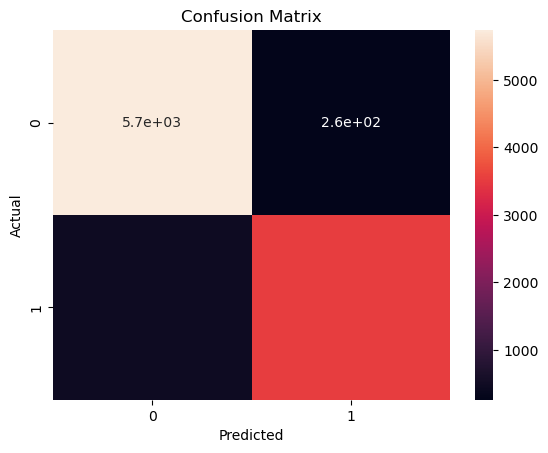

In [24]:
matrix = confusion_matrix(y_testN, y_predN)
plt.title("Confusion Matrix")
sns.heatmap(matrix, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Axes: >

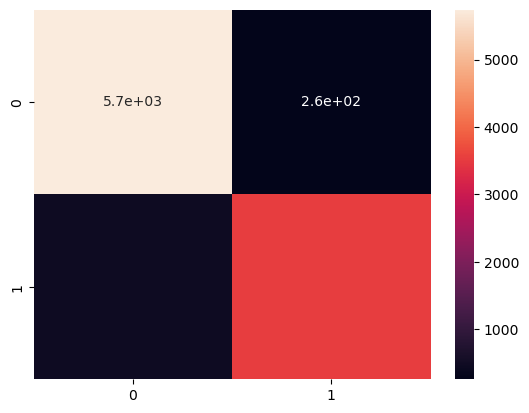

In [26]:
sns.heatmap(matrix, annot = True)

In [27]:
print(matrix)

[[5739  261]
 [ 466 3534]]


In [31]:
print(classification_report(y_testN, y_predN))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      6000
           1       0.93      0.88      0.91      4000

    accuracy                           0.93     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000

